In [6]:
# Librerias
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve
from scipy.interpolate import CubicSpline


In [7]:
def plot_FRAME(Mnod_frame, Melem_frame, UG_frame, scale=1.0, fixed_nodes=None,
               show_node_numbers=True, show_element_numbers=False):
    """
    Dibuja estructura FRAME 2D (no deformada en rojo, deformada en azul).
    - Mnod_frame: (Nnod,2) array de coordenadas.
    - Melem_frame: (Nelem, >=2) array de conectividad (1-based indices en las 2 primeras columnas).
    - UG_frame: vector de desplazamientos/rotaciones [u1,v1,th1, u2,v2,th2, ...]
    - scale: factor de amplificación de la deformada.
    - fixed_nodes: lista de nodos fijos (pueden ser 1-based o 0-based).
    - show_node_numbers / show_element_numbers: muestran numeración.
    """
    # --- validación y normalización ---
    Mnod_frame = np.asarray(Mnod_frame, dtype=float)
    Melem_frame = np.asarray(Melem_frame, dtype=float)
    UG = np.asarray(UG_frame).flatten()
    Nnod = Mnod_frame.shape[0]

    if UG.size != 3 * Nnod:
        raise ValueError(f"UG_frame size mismatch: esperado {3*Nnod}, recibido {UG.size}")

    plt.figure(figsize=(8,6))
    plt.grid(True)
    plt.axis('equal')

    # --- coordenadas deformadas ---
    X = Mnod_frame[:, 0] + scale * UG[0::3]
    Y = Mnod_frame[:, 1] + scale * UG[1::3]

    # --- dibujar elementos ---
    for i in range(Melem_frame.shape[0]):
        nod1 = int(Melem_frame[i, 0]) - 1
        nod2 = int(Melem_frame[i, 1]) - 1

        dofs = [3*nod1, 3*nod1+1, 3*nod1+2, 3*nod2, 3*nod2+1, 3*nod2+2]
        u1, v1, th1, u2, v2, th2 = UG[dofs]

        x1, y1 = Mnod_frame[nod1, :]
        x2, y2 = Mnod_frame[nod2, :]
        L = np.hypot(x2 - x1, y2 - y1)
        if L == 0:
            continue

        alfa = np.arctan2(y2 - y1, x2 - x1)
        c, s = np.cos(alfa), np.sin(alfa)
        R = np.array([[c, s], [-s, c]])

        # desplazamientos locales
        u1l, v1l = R @ np.array([u1, v1])
        u2l, v2l = R @ np.array([u2, v2])

        th1s = 0.0 if np.isnan(th1) else th1 * scale
        th2s = 0.0 if np.isnan(th2) else th2 * scale

        s_vals = np.linspace(0, L, 50)
        try:
            spline = CubicSpline([0, L], [v1l*scale, v2l*scale],
                                 bc_type=((1, th1s), (1, th2s)))
            v_s = spline(s_vals)
        except Exception:
            v_s = np.linspace(v1l*scale, v2l*scale, s_vals.size)

        u_s = np.linspace(u1l*scale, u2l*scale, s_vals.size)
        pts_local = np.vstack((s_vals + u_s, v_s)).T

        Rg = np.array([[c, -s], [s, c]])
        pts_global = pts_local @ Rg.T + np.array([x1, y1])

        plt.plot([x1, x2], [y1, y2], 'r--', linewidth=1.5, label='_nolegend_')
        plt.plot(pts_global[:, 0], pts_global[:, 1], 'b-', linewidth=2, label='_nolegend_')

        if show_element_numbers:
            xm, ym = np.mean([x1, x2]), np.mean([y1, y2])
            plt.text(xm, ym, f"e{i+1}", color='green', fontsize=8, ha='center')

    # --- nodos ---
    plt.plot(Mnod_frame[:, 0], Mnod_frame[:, 1], 'ro', markersize=5, label='nodos originales')
    plt.plot(X, Y, 'ob', markersize=4, label='nodos deformados')

    # --- marcar apoyos ---
    if fixed_nodes is not None:
        fixed_nodes = np.array(fixed_nodes, dtype=int)
        # aceptar índices 1-based
        if np.any(fixed_nodes >= Nnod):
            fixed_nodes = fixed_nodes - 1
        for idx in fixed_nodes:
            if 0 <= idx < Nnod:
                plt.plot(Mnod_frame[idx,0], Mnod_frame[idx,1], '^r',
                         markersize=10, markerfacecolor='r', label='_nolegend_')

    # --- numeración de nodos ---
    if show_node_numbers:
        for i, (xi, yi) in enumerate(Mnod_frame, start=1):
            plt.text(xi, yi + 0.02, str(i), fontsize=8, ha='center', color='blue')

    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title("Estructura FRAME 2D — deformada (azul) / no deformada (rojo)")
    plt.legend(loc='best', fontsize=9)
    plt.tight_layout()
    plt.show()

# Formulación de FRAME: superposición de BEAM + TRUSS
Para el caso debemos traer la matriz expandida de un truss y sumarla a una matriz expandida de de un BEAM, de este modo tendremos tres grados de libertad en cada uno de los nodos.

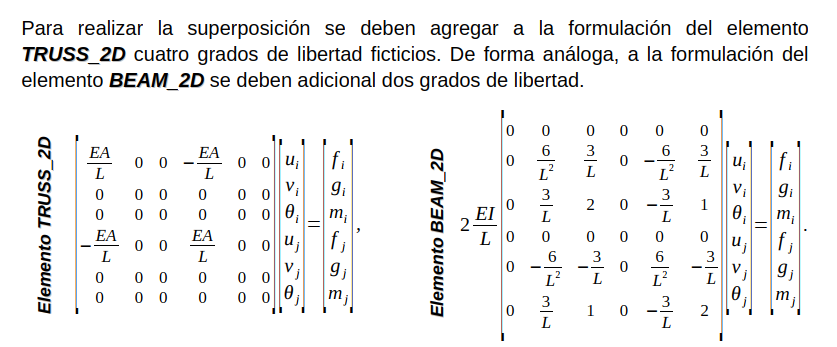
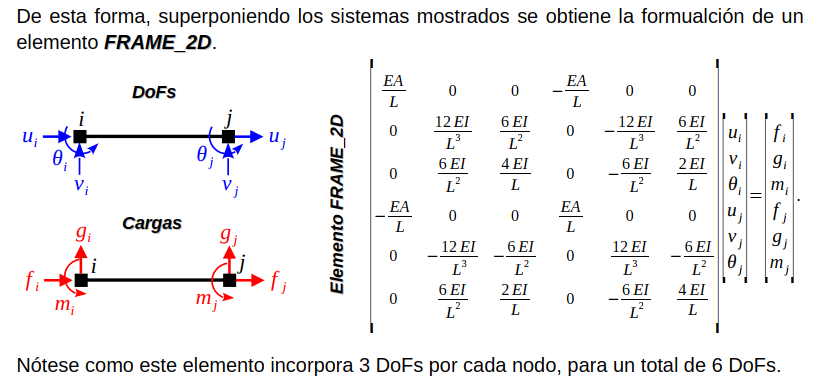

Para llevar los elementos de un sistema coordenado local a uno global hacemos uso de la matriz de rotación 

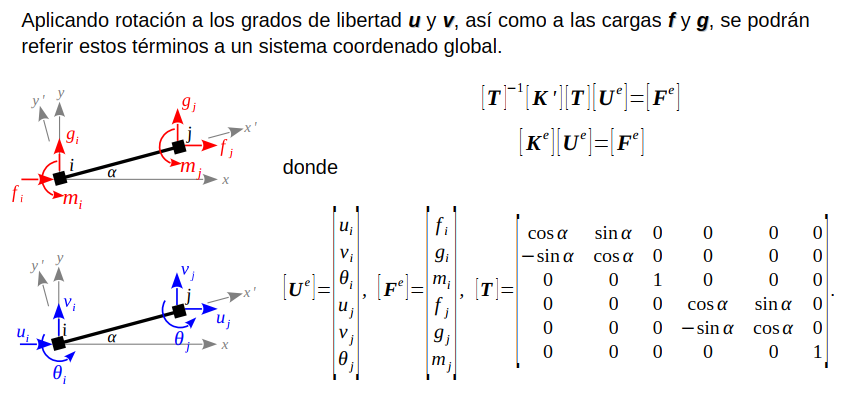

Como en el BEAM 1D las cargas distribuidas se deben expresar como un elementos cargado en sus nodos

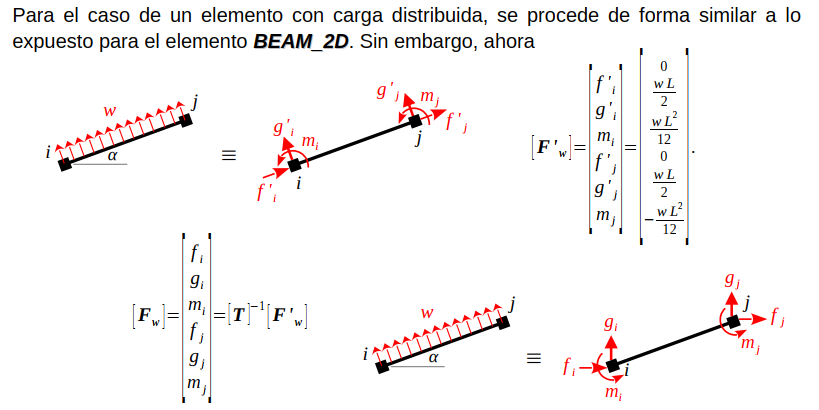

Los grados de libertad asociados a la elongación o compresión de los elementos, la parte TRUSS no se verá afectada por la forma de la carga distribuida


In [8]:

def mat_rot(alfa):
    "Matriz de rotación para elementos FRAME/TRUSS 2D"
    c = np.cos(alfa)
    s = np.sin(alfa)
    T = np.zeros((6,6))
    T[0,0] = c;  T[0,1] = s
    T[1,0] = -s; T[1,1] = c
    T[2,2] = 1
    T[3,3] = c;  T[3,4] = s
    T[4,3] = -s; T[4,4] = c
    T[5,5] = 1
    return T


def mat_Ke(Mnod, Melem, e):
    """Matriz de rigidez elemental (FRAME o TRUSS 2D)."""
    n1 = int(Melem[e,0]) - 1
    n2 = int(Melem[e,1]) - 1
    E  = Melem[e,2]
    A  = Melem[e,3]
    I  = Melem[e,4]
    tipo = int(Melem[e,5])

    x1, y1 = Mnod[n1]
    x2, y2 = Mnod[n2]
    L = np.hypot(x2-x1, y2-y1)
    alfa = np.arctan2(y2-y1, x2-x1)

    if tipo == 1:  # TRUSS
        Ke = np.array([
            [ E*A/L, 0, 0, -E*A/L, 0, 0],
            [ 0, 0, 0, 0, 0, 0],
            [ 0, 0, 0, 0, 0, 0],
            [-E*A/L, 0, 0, E*A/L, 0, 0],
            [ 0, 0, 0, 0, 0, 0],
            [ 0, 0, 0, 0, 0, 0]
        ])
    else:  # FRAME
        Ke = np.array([
            [ E*A/L,            0,              0, -E*A/L,           0,              0],
            [ 0,     12*E*I/L**3,   6*E*I/L**2,   0,    -12*E*I/L**3,   6*E*I/L**2],
            [ 0,      6*E*I/L**2,     4*E*I/L,    0,     -6*E*I/L**2,     2*E*I/L],
            [-E*A/L,            0,              0,  E*A/L,           0,              0],
            [ 0,    -12*E*I/L**3,  -6*E*I/L**2,  0,     12*E*I/L**3,  -6*E*I/L**2],
            [ 0,      6*E*I/L**2,     2*E*I/L,   0,     -6*E*I/L**2,     4*E*I/L]
        ])

    T = mat_rot(alfa)
    Ke = np.matmul(np.linalg.inv(T),Ke)
    Ke = np.matmul(Ke,T)
    return Ke


def mat_KG(Mnod, Melem):
    """Matriz de rigidez global."""
    Nnod = len(Mnod)
    KG = np.zeros((3*Nnod, 3*Nnod))
    for e in range(len(Melem)):
        n1 = int(Melem[e,0]) - 1
        n2 = int(Melem[e,1]) - 1
        dofs = np.array([3*n1,3*n1+1,3*n1+2,3*n2,3*n2+1,3*n2+2])
        Ke = mat_Ke(Mnod, Melem, e)
        for i in range(6):
            for j in range(6):
                KG[dofs[i], dofs[j]] += Ke[i,j]
    return KG


def vec_Fw(Mnod, Melem, e, w):
    """Carga distribuida vertical en vigas FRAME 2D."""
    n1 = int(Melem[e,0]) - 1
    n2 = int(Melem[e,1]) - 1
    x1, y1 = Mnod[n1]
    x2, y2 = Mnod[n2]
    L = np.hypot(x2 - x1, y2 - y1)
    tipo = int(Melem[e,5])
    
    if tipo == 1:  # sin carga distribuida para truss
        return np.zeros((6,1))
    
    # --- extraer componente vertical ---
    # w[e] puede ser un escalar o un vector [wx, wy, wθ]
    wi = w[e]
    if np.ndim(wi) == 0:
        wy = wi   # caso escalar
    else:
        wy = wi[1] if len(wi) > 1 else wi[0]  # componente vertical
    
    # --- vector de fuerzas nodales equivalentes ---
    Fw = np.array([
        [0],
        [wy * L / 2],
        [wy * L**2 / 12],
        [0],
        [wy * L / 2],
        [-wy * L**2 / 12]
    ])
    return Fw


def ensamble_Fw(Mnod, Melem, w):
    Nnod = len(Mnod)
    FwG = np.zeros((3*Nnod,1))
    for e in range(len(Melem)):
        Fw = vec_Fw(Mnod, Melem, e, w)
        n1 = int(Melem[e,0]) - 1
        n2 = int(Melem[e,1]) - 1
        dofs = [3*n1,3*n1+1,3*n1+2,3*n2,3*n2+1,3*n2+2]
        for i in range(6):
            FwG[dofs[i],0] += Fw[i,0]
    return FwG


def vec_FG(Mnod, Load):
    FG = np.zeros((3*len(Mnod),1))
    for i in range(len(Mnod)):
        for j in range(3):
            if not np.isnan(Load[3 * i + j, 0]):
                FG[3*i+j,0] += Load[3 * i + j, 0]
    return FG
def penalizacion(Mnod, Melem, BC_vector, kappa=1e12):
    """Penalización adaptada: truss sin momento, frame con momento."""
    Nnod = len(Mnod)
    Mpenaliz = np.zeros((3*Nnod, 3*Nnod))
    Vpenaliz = np.zeros((3*Nnod, 1))
    for i in range(3 * Nnod):
        if not np.isnan(BC_vector[i, 0]):
            Mpenaliz[i, i] = kappa
            Vpenaliz[i, 0] = kappa * BC_vector[i, 0]
    return Mpenaliz, Vpenaliz
def reacciones_directas(KG, UG, FG):
    return KG.dot(UG) - FG

def reacciones_con_penal(KG, Mpen, UG, FG, Vpen):
    Kp = KG + Mpen
    Fp = FG + Vpen
    return Kp.dot(UG) - Fp

def reacciones_por_particion(KG, UG, FG, BC_vector):
    ndof = KG.shape[0]
    fixed_idx = [i for i in range(ndof) if not np.isnan(BC_vector[i,0])]
    free_idx  = [i for i in range(ndof) if np.isnan(BC_vector[i,0])]
    if len(free_idx)==0:
        raise ValueError("No hay grados de libertad libres.")
    Kcf = KG[np.ix_(fixed_idx, free_idx)]
    Kcc = KG[np.ix_(fixed_idx, fixed_idx)]
    Uf = UG[free_idx, 0].reshape(-1,1)
    Uc = UG[fixed_idx, 0].reshape(-1,1)
    Fc = FG[fixed_idx, 0].reshape(-1,1)
    Rc = Kcf.dot(Uf) + Kcc.dot(Uc) - Fc
    R_global = np.zeros((ndof,1))
    for ii, idx in enumerate(fixed_idx):
        R_global[idx,0] = Rc[ii,0]
    return R_global, fixed_idx, free_idx


# Desarrollo de ejemplo de elementos combinados
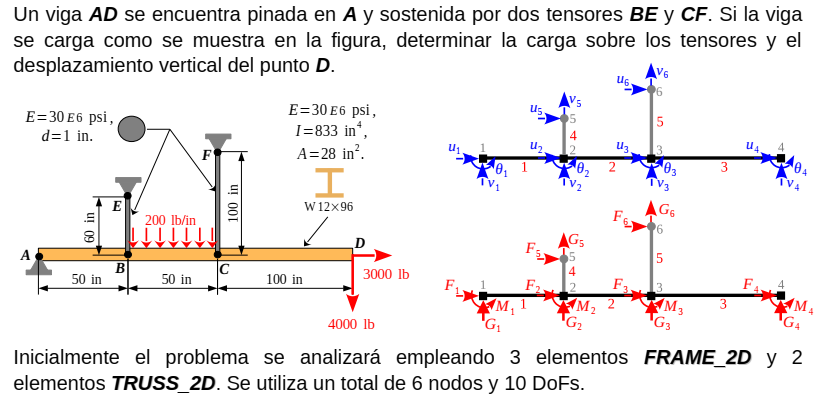


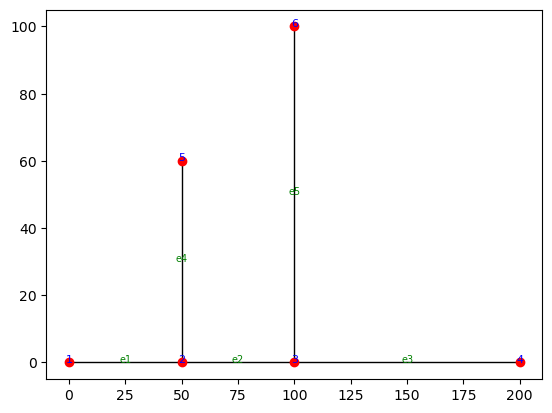

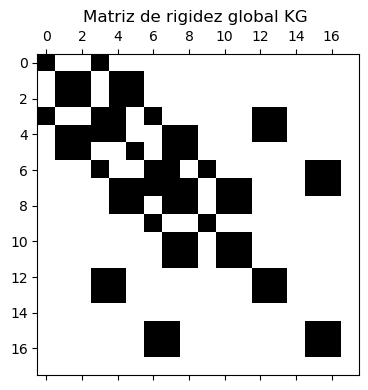

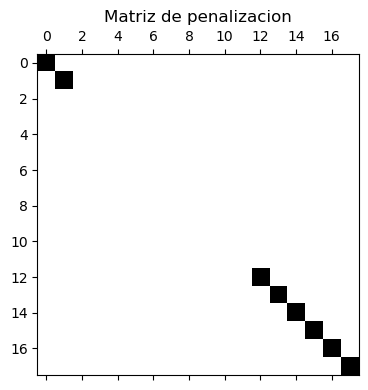

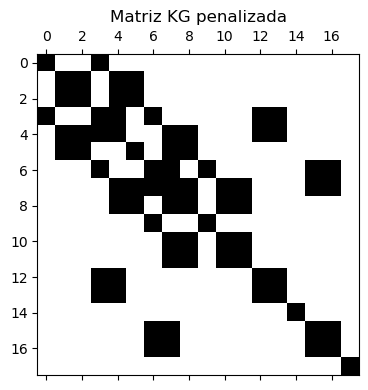

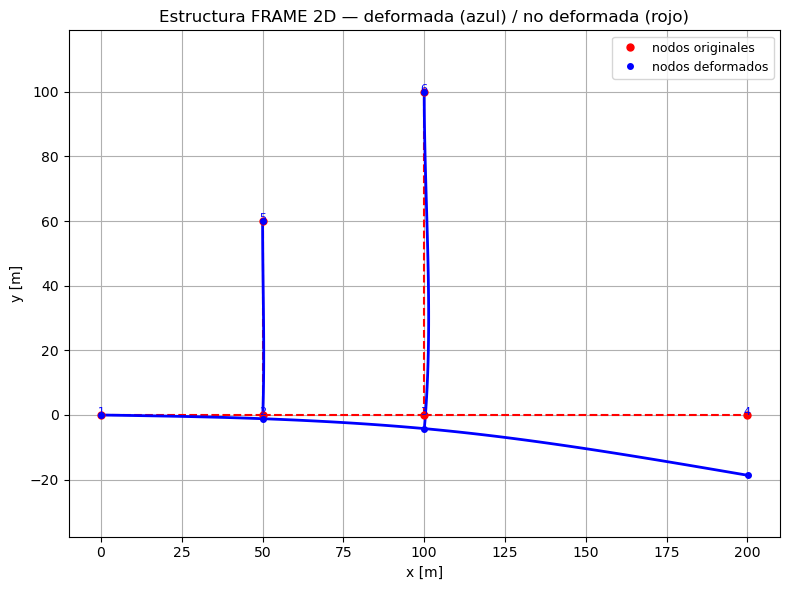

Reacciones (método directo KG@U - FG) en DOFs con BC:
  Nodo 1 Ux: -3000
  Nodo 1 Uy: -4368.8
  Nodo 5 Ux: 3.51326e-13
  Nodo 5 Uy: 5737.59
  Nodo 5 Theta: 0
  Nodo 6 Ux: 7.73438e-13
  Nodo 6 Uy: 12631.2
  Nodo 6 Theta: 0

Reacciones (método por partición) en DOFs con BC:
  Nodo 1 Ux: -3000
  Nodo 1 Uy: -4368.8
  Nodo 5 Ux: 3.51326e-13
  Nodo 5 Uy: 5737.59
  Nodo 5 Theta: 0
  Nodo 6 Ux: 7.73438e-13
  Nodo 6 Uy: 12631.2
  Nodo 6 Theta: 0


In [9]:
Mnod = np.array([
    [0, 0],      # 1: A
    [50, 0],     # 2: B
    [100, 0],    # 3: C
    [200, 0],    # 4: D
    [50, 60],    # 5: E (tensor)
    [100, 100]   # 6: F (tensor)
], dtype=np.float64)
# Propiedades
E = 30e6      # psi
A_truss = 1.0 # in^2
I_frame = 833 # in^4
A_frame = 28  # in^2
# Matriz de elementos: [nodo_i, nodo_j, E, A, I, tipo]
Melem = np.array([
    [1,2,E,A_frame,I_frame,2],  # AB FRAME
    [2,3,E,A_frame,I_frame,2],  # BC FRAME
    [3,4,E,A_frame,I_frame,2],  # CD FRAME
    [2,5,E,A_truss,0,1],        # BE TRUSS
    [3,6,E,A_truss,0,1]         # CF TRUSS
], dtype=float)
plt.figure()
# dibujar elementos
for e_idx, row in enumerate(Melem, start=1):
    n1, n2 = int(row[0])-1, int(row[1])-1
    plt.plot([Mnod[n1,0], Mnod[n2,0]], [Mnod[n1,1], Mnod[n2,1]], 'k-', lw=1)
Norig = len(Mnod[:,0])
plt.scatter(Mnod[:Norig,0], Mnod[:Norig,1], c='red', label='nodos originales', zorder=3)
for i,(xi,yi) in enumerate(Mnod, start=1):
    plt.text(xi, yi + 0.005, str(i), color='blue', fontsize=8, ha='center')
for ei,row in enumerate(Melem, start=1):
    n1, n2 = int(row[0])-1, int(row[1])-1
    xm, ym = (Mnod[n1,0]+Mnod[n2,0])/2, (Mnod[n1,1]+Mnod[n2,1])/2
    plt.text(xm, ym, f"e{ei}", color='green', fontsize=7, ha='center')
# Carga distribuida (-200 lb/in) solo en BC
w = np.array([0, -200, 0, 0, 0], dtype=float)
# Cargas nodales
Load = np.nan * np.ones((3*Mnod.shape[0],1))# incluye cargas y momentos Load [Fx;Fy;Mxy]
Load[9] = 3000.0
Load[10] = -4000.0
BC_vector = np.nan * np.ones((3*Mnod.shape[0],1))#  [ui;vi;thetai]
BC_vector[0] = 0.0
BC_vector[1] = 0.0
BC_vector[12:18] = 0.0
# ============================================================
# ENSAMBLAJE Y RESOLUCIÓN
# ============================================================
Nnod = len(Mnod)
KG = mat_KG(Mnod, Melem)
FG = vec_FG(Mnod, Load)
plt.figure(figsize=(5,4))
plt.spy(KG)
plt.title("Matriz de rigidez global KG ")
plt.tight_layout()
FwG = ensamble_Fw(Mnod, Melem, w)
FG = FG + FwG
Mpen, Vpen = penalizacion(Mnod, Melem, BC_vector, kappa=1e12)
plt.figure(figsize=(5,4))
plt.spy(Mpen)
plt.title("Matriz de penalizacion")
plt.tight_layout()
plt.figure(figsize=(5,4))
plt.spy(KG + Mpen)
plt.title("Matriz KG penalizada")
plt.tight_layout()
UG = np.linalg.solve(KG + Mpen,FG+Vpen)
plot_FRAME(Mnod, Melem, UG, scale=1e2, fixed_nodes=None,
               show_node_numbers=True, show_element_numbers=False)
R1 = reacciones_directas(KG, UG, FG)
print("Reacciones (método directo KG@U - FG) en DOFs con BC:")
for i in range(len(BC_vector)):
    if not np.isnan(BC_vector[i,0]):
        node = i//3 + 1; dof = i%3; name = ['Ux','Uy','Theta'][dof]
        print(f"  Nodo {node} {name}: {R1[i,0]:.6g}")

Rpar, fixed_idx, free_idx = reacciones_por_particion(KG, UG, FG, BC_vector)
print("\nReacciones (método por partición) en DOFs con BC:")
for idx in fixed_idx:
    node = idx//3 + 1; dof = idx%3; name = ['Ux','Uy','Theta'][dof]
    print(f"  Nodo {node} {name}: {Rpar[idx,0]:.6g}")

# Desarrollo de ejemplo Frame 2D con carga distribuida
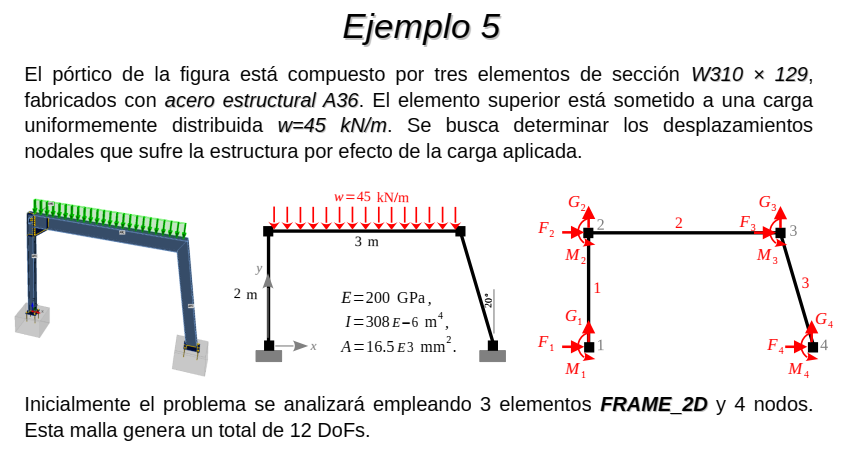

[[     0.]
 [     0.]
 [     0.]
 [     0.]
 [-67500.]
 [-33750.]
 [     0.]
 [-67500.]
 [ 33750.]
 [     0.]
 [     0.]
 [     0.]]
[[-2.93040257e-11]
 [-7.39302422e-11]
 [ 2.42504956e-11]
 [-1.53067561e-04]
 [-4.48062813e-05]
 [-1.64075627e-04]
 [-1.79707585e-04]
 [-1.11674574e-04]
 [ 2.76077340e-04]
 [ 2.93040257e-11]
 [-6.10697578e-11]
 [ 9.13925764e-13]]


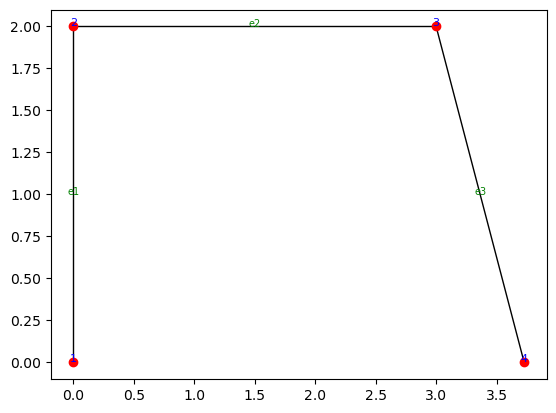

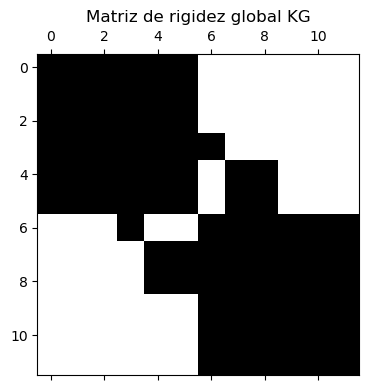

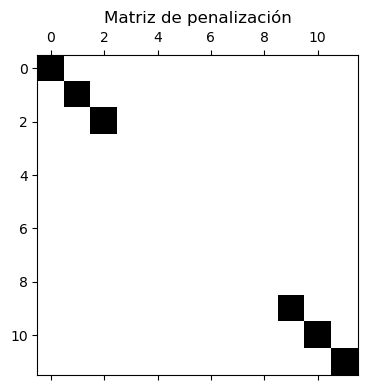

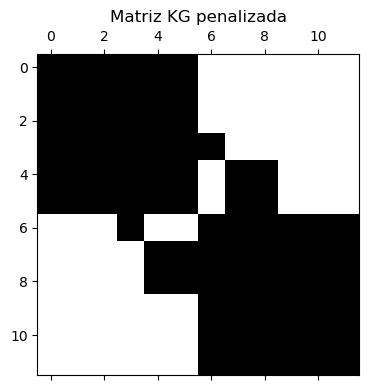

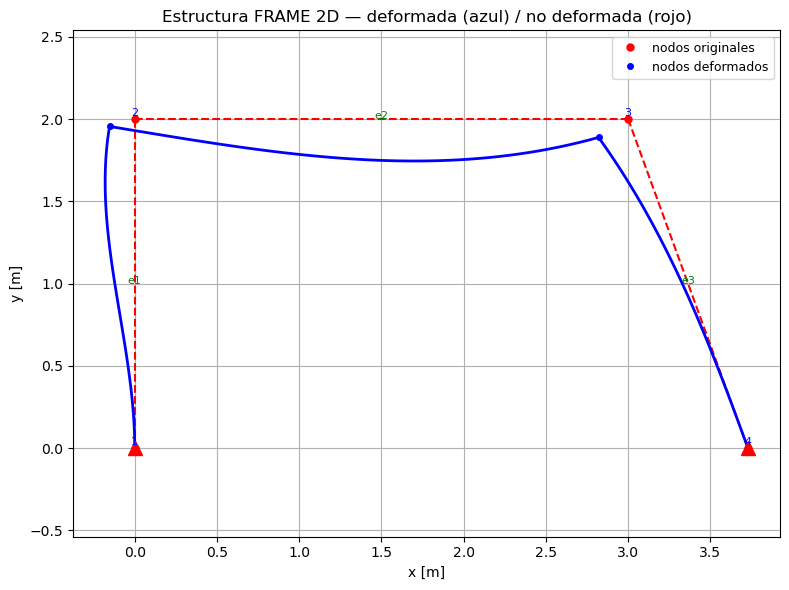

In [10]:
Mnod = np.array([
    [0.0, 0.0],   # 1
    [0.0, 2.0],   # 2
    [3.0, 2.0],   # 3
    [3.0 + 2*np.tan(np.deg2rad(20)), 0.0]    # 4
], dtype=float)

# Propiedades del material y la sección
E = 200e9                     # Pa (200 GPa)
I = 308e-6                    # m^4
A = 16.5e-3                   # m^2 (16.5E3 mm²)

# Matriz de conectividad de elementos
# Formato: [nodo_i, nodo_j, E, A, I, tipo]
# tipo=2 → FRAME_2D
Melem = np.array([
    [1, 2, E, A, I, 2],   # Columna izquierda
    [2, 3, E, A, I, 2],   # Viga superior
    [3, 4, E, A, I, 2]    # Columna derecha
], dtype=float)

# Dibujo preliminar de la estructura
plt.figure()
# dibujar elementos
for e_idx, row in enumerate(Melem, start=1):
    n1, n2 = int(row[0])-1, int(row[1])-1
    plt.plot([Mnod[n1,0], Mnod[n2,0]], [Mnod[n1,1], Mnod[n2,1]], 'k-', lw=1)
Norig = len(Mnod[:,0])
plt.scatter(Mnod[:Norig,0], Mnod[:Norig,1], c='red', label='nodos originales', zorder=3)
for i,(xi,yi) in enumerate(Mnod, start=1):
    plt.text(xi, yi + 0.005, str(i), color='blue', fontsize=8, ha='center')
for ei,row in enumerate(Melem, start=1):
    n1, n2 = int(row[0])-1, int(row[1])-1
    xm, ym = (Mnod[n1,0]+Mnod[n2,0])/2, (Mnod[n1,1]+Mnod[n2,1])/2
    plt.text(xm, ym, f"e{ei}", color='green', fontsize=7, ha='center')

# ============================================================
# CARGAS
# ============================================================
# Se aplica solo en el segundo elemento FRAME (2–3)
w_global = np.array([0.0, -45e3, 0.0])  # posición según índice de elemento
# Cargas nodales (Fx, Fy, M)
Load = np.nan * np.ones((3*Mnod.shape[0], 1))
# No hay cargas puntuales, solo la distribuida sobre el elemento 2
# ============================================================
# CONDICIONES DE APOYO (DESPLAZAMIENTOS CONOCIDOS)
# ============================================================
BC_vector = np.nan * np.ones((3*Mnod.shape[0], 1))
# Nodo 1 empotrado (u=v=θ=0)
BC_vector[0:3] = 0.0
# Nodo 4 empotrado (u=v=θ=0)
BC_vector[9:12] = 0.0
# ============================================================
# ENSAMBLAJE Y RESOLUCIÓN
# ============================================================
Nnod = len(Mnod)
KG = mat_KG(Mnod, Melem)
plt.figure(figsize=(5,4))
plt.spy(KG)
plt.title("Matriz de rigidez global KG")
plt.tight_layout()
FG = vec_FG(Mnod, Load)
FwG = ensamble_Fw(Mnod, Melem, w_global)
print(FwG)
FG = FG + FwG
Mpen, Vpen = penalizacion(Mnod, Melem, BC_vector, kappa=1e15)
plt.figure(figsize=(5,4))
plt.spy(Mpen)
plt.title("Matriz de penalización")
plt.tight_layout()
plt.figure(figsize=(5,4))
plt.spy(KG + Mpen)
plt.title("Matriz KG penalizada")
plt.tight_layout()
# Solución de desplazamientos
UG = np.linalg.solve(KG + Mpen, FG + Vpen)
print(UG)
# ============================================================
# POSTPROCESO
# ============================================================
plot_FRAME(Mnod, Melem, UG, scale=1e3, fixed_nodes=[1, 4],
            show_node_numbers=True, show_element_numbers=True)

In [11]:
def MnodANDMelem_FRAME_2D(Mnod, Melem, E, I, A, Nelem_seg=1, decimals=12):
    """
    Refina una malla 2D subdividiendo cada elemento FRAME en Nelem_seg partes.

    Parámetros:
      Mnod : (Nnod,2) -> coordenadas [x, y]
      Melem : (Nelem,2) -> conectividades (1-based)
      E, I, A : propiedades de los elementos
      Nelem_seg : subdivisiones por elemento (int o lista)
      decimals : precisión de redondeo para evitar duplicados numéricos

    Retorna:
      Mnod_new : (Nnod_total,2)
      Melem_new : (Nelem_total,5) con columnas [n1, n2, E, A, I]
    """

    Mnod = np.asarray(Mnod, dtype=float)
    Melem = np.asarray(Melem, dtype=int)

    # --- Subdivisiones por elemento ---
    if np.isscalar(Nelem_seg):
        segs = [int(Nelem_seg)] * Melem.shape[0]
    else:
        segs = list(map(int, np.asarray(Nelem_seg)))
        if len(segs) != Melem.shape[0]:
            raise ValueError("Nelem_seg debe tener un valor por elemento.")

    # --- Nodos y mapa (para evitar duplicados) ---
    nodes = [tuple(Mnod[i, :]) for i in range(Mnod.shape[0])]
    coords_map = { (round(x, decimals), round(y, decimals)) : i+1 for i, (x,y) in enumerate(nodes) }
    next_idx = len(nodes) + 1
    elementos = []

    # --- Bucle por elemento ---
    for e, (n1, n2) in enumerate(Melem):
        x1, y1 = Mnod[n1-1, :]
        x2, y2 = Mnod[n2-1, :]
        s = segs[e]
        t = np.linspace(0, 1, s+1)  # parámetros de subdivisión

        # Nodos a lo largo del elemento
        node_ids_along = []
        for ti in t:
            xi = x1*(1-ti) + x2*ti
            yi = y1*(1-ti) + y2*ti
            key = (round(xi, decimals), round(yi, decimals))
            idx = coords_map.get(key)
            if idx is None:
                coords_map[key] = next_idx
                nodes.append((xi, yi))
                idx = next_idx
                next_idx += 1
            node_ids_along.append(idx)

        # Crear subelementos entre nodos consecutivos
        for j in range(len(node_ids_along)-1):
            elementos.append([node_ids_along[j], node_ids_along[j+1], E, A, I])

    # --- Empaquetar resultados ---
    Mnod_new = np.array(nodes, dtype=float)
    Melem_new = np.array(elementos, dtype=float)

    return Mnod_new, Melem_new
def expand_BC_vector(BC_vector, Mnod_old, Mnod_new, tol=1e-9):
    """
    Expande las condiciones de contorno a la nueva malla refinada.

    - Los nodos originales mantienen sus restricciones.
    - Los nodos nuevos (intermedios) quedan libres (NaN).

    Parámetros:
      BC_vector : (3*Nnod_old, 1) -> desplazamientos conocidos (NaN o valor)
      Mnod_old  : (Nnod_old, 2)
      Mnod_new  : (Nnod_new, 2)
      tol       : tolerancia para identificar nodos coincidentes

    Retorna:
      BC_new : (3*Nnod_new, 1)
    """
    Nold = Mnod_old.shape[0]
    Nnew = Mnod_new.shape[0]
    BC_new = np.nan * np.ones((3 * Nnew, 1))

    for i_old in range(Nold):
        x_old, y_old = Mnod_old[i_old]
        # Buscar el nodo correspondiente en la malla refinada
        d = np.linalg.norm(Mnod_new - [x_old, y_old], axis=1)
        idx_match = np.argmin(d)
        if d[idx_match] < tol:
            BC_new[3*idx_match:3*idx_match+3] = BC_vector[3*i_old:3*i_old+3]

    return BC_new
def expand_Load_vector(Load, Mnod_old, Mnod_new, tol=1e-9):
    """
    Expande las cargas nodales a la nueva malla refinada.

    Parámetros:
      Load : (3*Nnod_old, 1)
      Mnod_old, Mnod_new : coordenadas de nodos
      tol : tolerancia para coincidencia

    Retorna:
      Load_new : (3*Nnod_new, 1)
    """
    Nold = Mnod_old.shape[0]
    Nnew = Mnod_new.shape[0]
    Load_new = np.nan * np.ones((3 * Nnew, 1))

    for i_old in range(Nold):
        x_old, y_old = Mnod_old[i_old]
        d = np.linalg.norm(Mnod_new - [x_old, y_old], axis=1)
        idx_match = np.argmin(d)
        if d[idx_match] < tol:
            Load_new[3*idx_match:3*idx_match+3] = Load[3*i_old:3*i_old+3]

    return Load_new
def expand_w_global(w_global, Melem_old, Melem_new, Nelem_seg):
    """
    Expande la carga distribuida por elemento al caso refinado.

    Parámetros:
      w_global : (Nelem_old, 3)  o (3,) si es igual para todos
      Melem_old, Melem_new : conectividades antiguas y nuevas
      Nelem_seg : subdivisiones por elemento (int o lista)

    Retorna:
      w_global_new : (Nelem_new, 3)
    """
    Melem_old = np.asarray(Melem_old, int)
    Melem_new = np.asarray(Melem_new, int)

    if w_global.ndim == 1:
        w_global = np.tile(w_global, (Melem_old.shape[0], 1))

    if np.isscalar(Nelem_seg):
        Nelem_seg = [Nelem_seg] * Melem_old.shape[0]

    w_expanded = []
    for i, seg in enumerate(Nelem_seg):
        for _ in range(seg):
            w_expanded.append(w_global[i])

    return np.array(w_expanded)


[[1.00000000e+00 2.00000000e+00 2.00000000e+11 4.90873852e-04
  1.91747598e-08 2.00000000e+00]
 [2.00000000e+00 3.00000000e+00 2.00000000e+11 4.90873852e-04
  1.91747598e-08 2.00000000e+00]]


<Figure size 640x480 with 0 Axes>

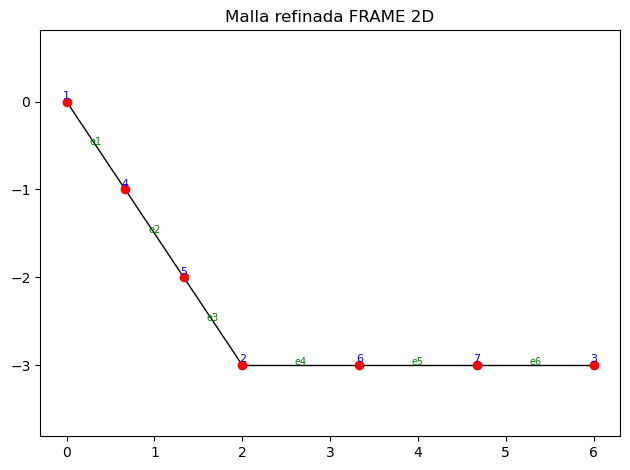

C:\Users\david\AppData\Local\Temp\ipykernel_19996\2997279350.py:129: RuntimeWarning: invalid value encountered in cast
  Melem_old = np.asarray(Melem_old, int)
C:\Users\david\AppData\Local\Temp\ipykernel_19996\2997279350.py:130: RuntimeWarning: invalid value encountered in cast
  Melem_new = np.asarray(Melem_new, int)


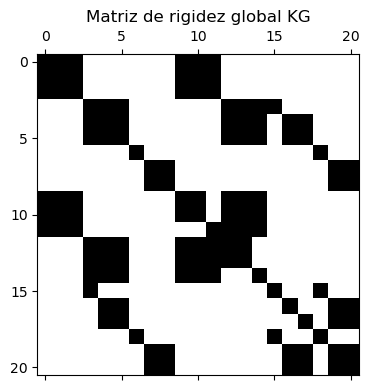

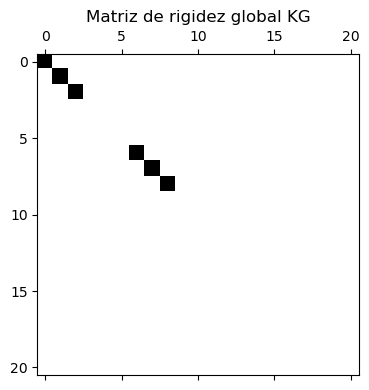

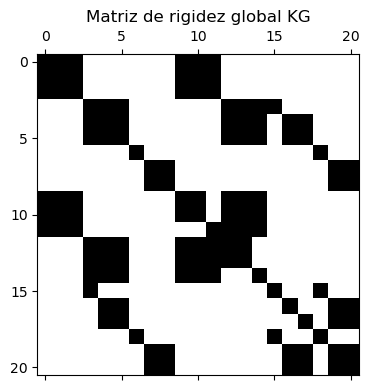

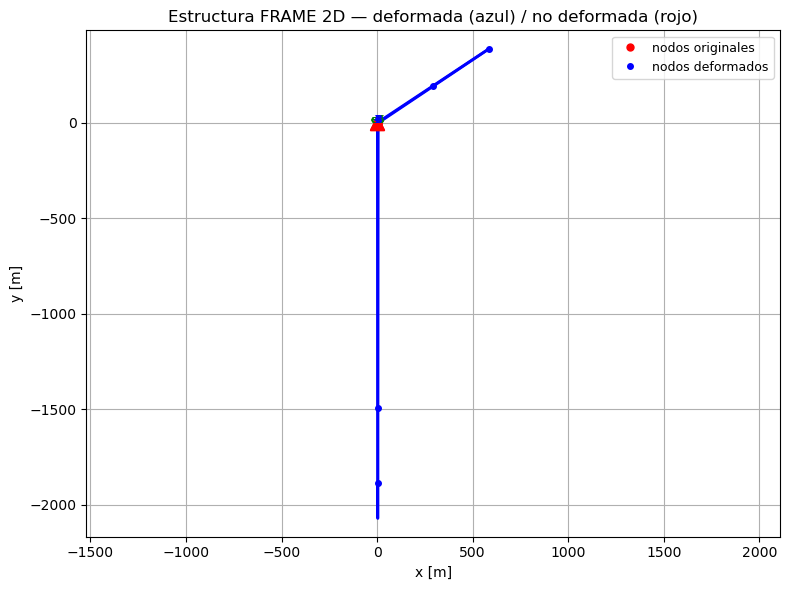

In [15]:
# ============================================================
# GEOMETRÍA ORIGINAL
# ============================================================
# Mnod = np.array([
#     [0.0, 0.0],   # 1
#     [0.0, 2.0],   # 2
#     [3.0, 2.0],   # 3
#     [3.0 + 2*np.tan(np.deg2rad(20)), 0.0]    # 4
# ], dtype=float)

# # Propiedades del material y la sección
# E = 200e9       # Pa (200 GPa)
# I = 308e-6      # m^4
# A = 16.5e-3     # m^2

# # Matriz de conectividad (elementos originales)
# Melem = np.array([
#     [1, 2, E, A, I, 2],   # Columna izquierda
#     [2, 3, E, A, I, 2],   # Viga superior
#     [3, 4, E, A, I, 2]    # Columna derecha
# ], dtype=float)
Mnod = np.array([
    [0,0],
    [2,-3],
    [6,-3]],dtype=np.float64)
# Mnod = np.array([
#     [6,-3],
#     [2,-3],
#     [0,0]],dtype=np.float64)
E = 200e9
d = 25e-3
A = np.pi/4 * (d**2)
I = np.pi/4 * (d/2)**4
Melem=np.array([
    [1,2,E,A,I,2],
    [2,3,E,A,I,2]],dtype=np.float64)
plt.figure()
conectividades = Melem[:, :2].astype(int)

# ============================================================
# CARGAS
# ============================================================
# Se aplica solo en el segundo elemento FRAME (2–3)
w_global = np.array([[0.0], [-8e3]])
Load = np.nan * np.ones((3 * Mnod.shape[0], 1))  # cargas nodales vacías
Load 
# ============================================================
# CONDICIONES DE APOYO (DESPLAZAMIENTOS CONOCIDOS)
# ============================================================
BC_vector = np.nan * np.ones((3 * Mnod.shape[0], 1))
BC_vector[0:3] = 0.0       # nodo 1 empotrado
BC_vector[-3:] = 0.0      # nodo 4 empotrado

# ============================================================
# REFINAMIENTO DE MALLA
# ============================================================
Mnod_ref, Melem_ref = MnodANDMelem_FRAME_2D(Mnod, conectividades, E, I, A, Nelem_seg=3)
Melem_ref = np.hstack([Melem_ref, 2 * np.ones((Melem_ref.shape[0], 1))])
print(Melem)
# ============================================================
# DIBUJO DE LA MALLA REFINADA
# ============================================================
plt.figure()
for e_idx, row in enumerate(Melem_ref, start=1):
    n1, n2 = int(row[0])-1, int(row[1])-1
    plt.plot([Mnod_ref[n1, 0], Mnod_ref[n2, 0]],
             [Mnod_ref[n1, 1], Mnod_ref[n2, 1]], 'k-', lw=1)
plt.scatter(Mnod_ref[:, 0], Mnod_ref[:, 1], c='red', zorder=3, label='nodos refinados')

for i, (xi, yi) in enumerate(Mnod_ref, start=1):
    plt.text(xi, yi + 0.03, str(i), color='blue', fontsize=8, ha='center')
for ei, row in enumerate(Melem_ref, start=1):
    n1, n2 = int(row[0])-1, int(row[1])-1
    xm, ym = (Mnod_ref[n1,0]+Mnod_ref[n2,0])/2, (Mnod_ref[n1,1]+Mnod_ref[n2,1])/2
    plt.text(xm, ym, f"e{ei}", color='green', fontsize=7, ha='center')
plt.axis('equal')
plt.title("Malla refinada FRAME 2D")
plt.tight_layout()
plt.show()

# ============================================================
# EXPANDIR CONDICIONES Y CARGAS
# ============================================================
BC_ref = expand_BC_vector(BC_vector, Mnod, Mnod_ref)
# print(BC_ref)
Load_ref = expand_Load_vector(Load, Mnod, Mnod_ref)
# print(Load_ref)
w_ref = expand_w_global(w_global, Melem, Melem_ref, Nelem_seg=3)
# print(w_ref)

# ============================================================
# ENSAMBLAJE Y SOLUCIÓN
# ============================================================
KG = mat_KG(Mnod_ref, Melem_ref)
plt.figure(figsize=(5,4))
plt.spy(KG)
plt.title("Matriz de rigidez global KG")
plt.tight_layout()
FG = vec_FG(Mnod_ref, Load_ref)
FwG = ensamble_Fw(Mnod_ref, Melem_ref, w_ref)
# print(FwG)
FG = FG + FwG
Mpen, Vpen = penalizacion(Mnod_ref, Melem_ref, BC_ref, kappa=1e15)
plt.figure(figsize=(5,4))
plt.spy(Mpen)
plt.title("Matriz de rigidez global KG")
plt.tight_layout()
plt.figure(figsize=(5,4))
plt.spy(Mpen+KG)
plt.title("Matriz de rigidez global KG")
plt.tight_layout()
UG_ref = np.linalg.solve(KG+ Mpen, FG + Vpen)

# ============================================================
# POSTPROCESO
# ============================================================
plot_FRAME(Mnod_ref, Melem_ref, UG_ref, scale=1e3, fixed_nodes=[1, 4],
           show_node_numbers=True, show_element_numbers=True)

In [ ]:
Mnod = np.array([[0 ,0],
                 [3 ,0],
                 [6, 0],
                 [3*np.cos(np.deg2rad(45)),3*np.sin(np.deg2rad(45))],
                 [6-2.2*np.cos(np.deg2rad(28.7)),2.2*np.sin(np.deg2rad(28.7))]],dtype=np.float64)
E = 210e9
d = 30e-3
Melem = np.array([[1,2,E,d,2],
                 [2,3,E,d,2],
                 [1,4,E,d,2],
                 [2,5,E,d,2],
                 [2,4,E,d,2],
                 [4,5,E,d,2],
                 [5,3,E,d,2]],dtype=np.float64)
def mat_rot(alfa):
    "Matriz de rotación para elementos FRAME/TRUSS 2D"
    c = np.cos(alfa)
    s = np.sin(alfa)
    T = np.zeros((6,6))
    T[0,0] = c;  T[0,1] = s
    T[1,0] = -s; T[1,1] = c
    T[2,2] = 1
    T[3,3] = c;  T[3,4] = s
    T[4,3] = -s; T[4,4] = c
    T[5,5] = 1
    return T
def mat_Ke(Mnod, Melem, e):
    n1 = int(Melem[e,0]) - 1
    n2 = int(Melem[e,1]) - 1
    E  = Melem[e,2]
    d = Melem[e,3]
    A = np.pi*(d/2)**2
    I = np.pi/4 * (d/2)**4
    x1, y1 = Mnod[n1]
    x2, y2 = Mnod[n2]
    L = np.hypot(x2-x1, y2-y1)
    alfa = np.arctan2(y2-y1, x2-x1)
    Ke = np.array([
            [ E*A/L,            0,              0, -E*A/L,           0,              0],
            [ 0,     12*E*I/L**3,   6*E*I/L**2,   0,    -12*E*I/L**3,   6*E*I/L**2],
            [ 0,      6*E*I/L**2,     4*E*I/L,    0,     -6*E*I/L**2,     2*E*I/L],
            [-E*A/L,            0,              0,  E*A/L,           0,              0],
            [ 0,    -12*E*I/L**3,  -6*E*I/L**2,  0,     12*E*I/L**3,  -6*E*I/L**2],
            [ 0,      6*E*I/L**2,     2*E*I/L,   0,     -6*E*I/L**2,     4*E*I/L]
        ])
    T = mat_rot(alfa)
    Ke = np.linalg.matmul(np.linalg.inv(T),Ke)
    Ke = np.linalg.matmul(Ke,T)
    return Ke
def mat_KG(Mnod, Melem):
    """Matriz de rigidez global."""
    Nnod = len(Mnod)
    KG = np.zeros((3*Nnod, 3*Nnod))
    for e in range(len(Melem)):
        n1 = int(Melem[e,0]) - 1
        n2 = int(Melem[e,1]) - 1
        dofs = np.array([3*n1,3*n1+1,3*n1+2,3*n2,3*n2+1,3*n2+2])
        Ke = mat_Ke(Mnod, Melem, e)
        for i in range(6):
            for j in range(6):
                KG[dofs[i], dofs[j]] += Ke[i,j]
    return KG
Load = np.nan * np.ones((3*Mnod.shape[0], 1))
Load[10,0] = -5e3
Load[13,0] = -3e3
print(Load)
BC_vector = np.nan * np.ones((3*Mnod.shape[0], 1))
BC_vector[0:3,0] = 0
BC_vector[7,0] = 0
BC_vector[8,0] = 0
print(BC_vector)
Nnod = len(Mnod)
KG = mat_KG(Mnod, Melem)
print(KG)
plt.figure(figsize=(5,4))
plt.spy(KG)
plt.title("Matriz de rigidez global KG")
plt.tight_layout()
FG = vec_FG(Mnod, Load)
FG = FG 
Mpen, Vpen = penalizacion(Mnod, Melem, BC_vector, kappa=1e15)
plt.figure(figsize=(5,4))
plt.spy(Mpen)
plt.title("Matriz de penalización")
plt.tight_layout()
plt.figure(figsize=(5,4))
plt.spy(KG + Mpen)
plt.title("Matriz KG penalizada")
plt.tight_layout()
# Solución de desplazamientos
UG = np.linalg.solve(KG + Mpen, FG + Vpen)
print(UG)
# ============================================================
# POSTPROCESO
# ============================================================
plot_FRAME(Mnod, Melem, UG, scale=1e3, fixed_nodes=[1, 4],
            show_node_numbers=True, show_element_numbers=True)